# COVID-19: Global Spread and Government Response

Notebook prepares the main analysis and visualizations for our project on COVID-19 spread and government responses.

Two datasets from Google's COVID-19 Open Data:

1. **Epidemiology**
2. **Oxford Government Response**

Our goal is to:
- understand the global development of infections and deaths,
- examine government stringency over time,
- compare selected countries,
- and visualize the global spread of COVID-19 on a world map.

A key preprocessing decision is to use **country-level rows only**.  
The epidemiology dataset contains country, regional, and local rows, and using all of them together would lead to **double-counting**. Therefore, we keep only rows where `location_key` contains no underscore.

## Imports

We begin by importing the libraries needed for data handling, plotting, and country-code conversion.

In [75]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.express as px

import pycountry

## Load data

The paths below assume the notebook is placed in a folder next to a `data` folder containing:

- `epidemiology.csv`
- `oxford-government-response.csv`

In [76]:
current_dir = Path.cwd()

data_path1 = current_dir.parent / "data" / "epidemiology.csv"
data_path2 = current_dir.parent / "data" / "oxford-government-response.csv"

epi = pd.read_csv(data_path1, parse_dates=["date"], low_memory=False)
gov = pd.read_csv(data_path2, parse_dates=["date"], low_memory=False)

print("Epidemiology shape:", epi.shape)
print("Government response shape:", gov.shape)

Epidemiology shape: (12525825, 10)
Government response shape: (303969, 22)


## Initial inspection

Before cleaning the data, we inspect the basic structure of the datasets:
- number of rows and columns,
- variable names,
- and date coverage.

In [77]:
print("Epidemiology columns:")
print(epi.columns.tolist())

print("\nGovernment response columns:")
print(gov.columns.tolist())

print("\nEpidemiology date range:", epi["date"].min(), "to", epi["date"].max())
print("Government response date range:", gov["date"].min(), "to", gov["date"].max())

Epidemiology columns:
['date', 'location_key', 'new_confirmed', 'new_deceased', 'new_recovered', 'new_tested', 'cumulative_confirmed', 'cumulative_deceased', 'cumulative_recovered', 'cumulative_tested']

Government response columns:
['date', 'location_key', 'school_closing', 'workplace_closing', 'cancel_public_events', 'restrictions_on_gatherings', 'public_transport_closing', 'stay_at_home_requirements', 'restrictions_on_internal_movement', 'international_travel_controls', 'income_support', 'debt_relief', 'fiscal_measures', 'international_support', 'public_information_campaigns', 'testing_policy', 'contact_tracing', 'emergency_investment_in_healthcare', 'investment_in_vaccines', 'facial_coverings', 'vaccination_policy', 'stringency_index']

Epidemiology date range: 2019-12-31 00:00:00 to 2022-12-30 00:00:00
Government response date range: 2020-01-01 00:00:00 to 2022-07-27 00:00:00


## Keep country-level rows only

Both datasets contain multiple geographic levels.  
For example, a country may appear as:

- `DK` → country level
- `US_CA` → state or region level
- `BR_SP_3550308` → local level

To avoid double-counting, we keep only **country-level rows**, defined as rows where `location_key` contains **no underscore**.

In [78]:
epi_country = epi[epi["location_key"].astype(str).str.count("_") == 0].copy()
gov_country = gov[gov["location_key"].astype(str).str.count("_") == 0].copy()

print("Country-level epidemiology shape:", epi_country.shape)
print("Country-level government response shape:", gov_country.shape)

print("Unique country-level keys in epidemiology:", epi_country["location_key"].nunique())
print("Unique country-level keys in government response:", gov_country["location_key"].nunique())

Country-level epidemiology shape: (227879, 10)
Country-level government response shape: (172116, 22)
Unique country-level keys in epidemiology: 232
Unique country-level keys in government response: 186


## Clean daily variables

Daily COVID time series often contain negative values due to retrospective reporting corrections.

For the main visualizations, we clip negative daily values to zero in order to produce cleaner and more interpretable plots.  
This is especially useful for introductory visualizations in the video and website.

In [79]:
for col in ["new_confirmed", "new_deceased", "new_recovered", "new_tested"]:
    if col in epi_country.columns:
        epi_country[col] = epi_country[col].clip(lower=0)

## Country-code conversion for maps

The datasets use ISO-2 style country codes such as:

- `DK`
- `SE`
- `US`
- `BR`

Plotly choropleth maps work best with **ISO-3** codes such as:

- `DNK`
- `SWE`
- `USA`
- `BRA`

We therefore define a converter from ISO-2 to ISO-3 using `pycountry`.  
We also add a manual special case for Kosovo (`XK`).

In [80]:
special_cases = {
    "XK": "XKX",  # Kosovo
}

def iso2_to_iso3(code):
    if pd.isna(code):
        return None
    code = str(code).strip().upper()
    if code in special_cases:
        return special_cases[code]
    country = pycountry.countries.get(alpha_2=code)
    return country.alpha_3 if country else None

## Verify country-code conversion

Before building the world map, check that all country-level rows can be converted successfully.

In [81]:
latest_cases_check = (
    epi_country.sort_values("date")
    .groupby("location_key", as_index=False)["cumulative_confirmed"]
    .last()
    .copy()
)

latest_cases_check["iso3"] = latest_cases_check["location_key"].apply(iso2_to_iso3)

print("Total country rows:", len(latest_cases_check))
print("Mapped to ISO-3:", latest_cases_check["iso3"].notna().sum())
print("Failed mappings:", latest_cases_check["iso3"].isna().sum())

failed_codes = sorted(latest_cases_check.loc[latest_cases_check["iso3"].isna(), "location_key"].unique())
print("Failed codes:", failed_codes)

Total country rows: 232
Mapped to ISO-3: 232
Failed mappings: 0
Failed codes: []


## Visual style

Use a consistent visual style across all charts:

- dark slate background: `#4C616C`
- light text: `#F0F0F0`
- deep blue for infections: `#202983`
- dark red for deaths and response overlays: `#9D0011`

In [82]:
BG = "#4C616C"
TEXT = "#F0F0F0"
GRID = "#6F838D"
BLUE = "#202983"
RED = "#9D0011"
LIGHT_FILL = "#D8E0E4"

mpl.rcParams["figure.facecolor"] = BG
mpl.rcParams["axes.facecolor"] = BG
mpl.rcParams["savefig.facecolor"] = BG
mpl.rcParams["axes.edgecolor"] = TEXT
mpl.rcParams["axes.labelcolor"] = TEXT
mpl.rcParams["xtick.color"] = TEXT
mpl.rcParams["ytick.color"] = TEXT
mpl.rcParams["text.color"] = TEXT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = GRID
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.grid"] = True

## Global infections over time

This figure shows the global number of new confirmed COVID-19 cases over time, aggregated across country-level rows only.

We smooth the daily data using a **7-day rolling average** in order to reduce reporting noise and make the major global waves easier to see.

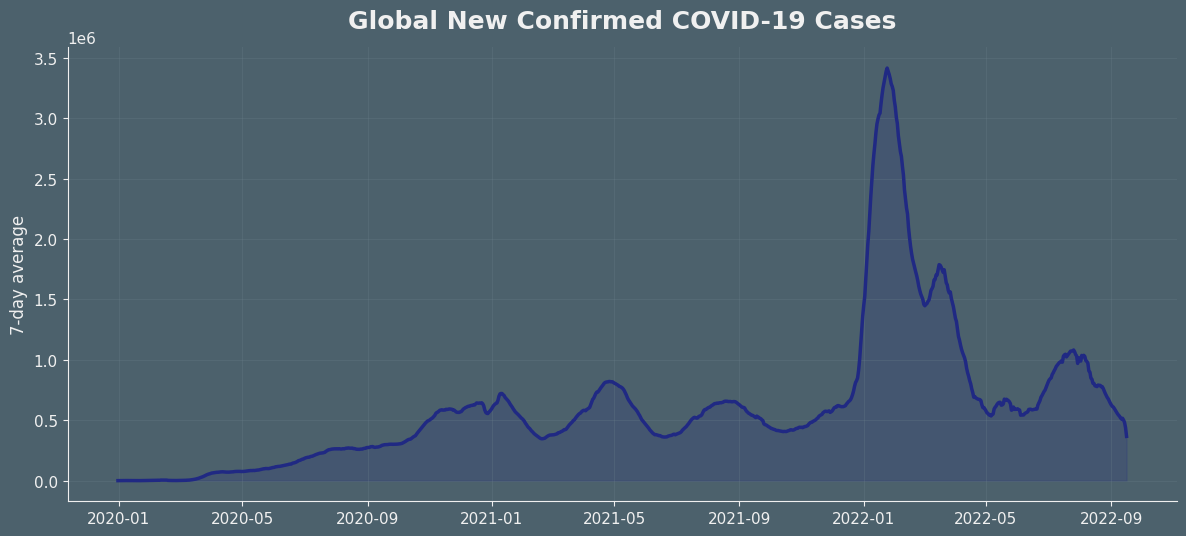

In [83]:
global_cases = (
    epi_country.groupby("date")["new_confirmed"]
    .sum()
    .rolling(7, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(global_cases.index, global_cases.values, color=BLUE, linewidth=2.5)
ax.fill_between(global_cases.index, global_cases.values, color=BLUE, alpha=0.18)

ax.set_title("Global New Confirmed COVID-19 Cases", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Global deaths over time

This figure shows the global number of new COVID-19 deaths over time, again using country-level rows only and a 7-day rolling average.

Compared with the infections plot, this figure emphasizes the severity and timing of the pandemic's major waves.

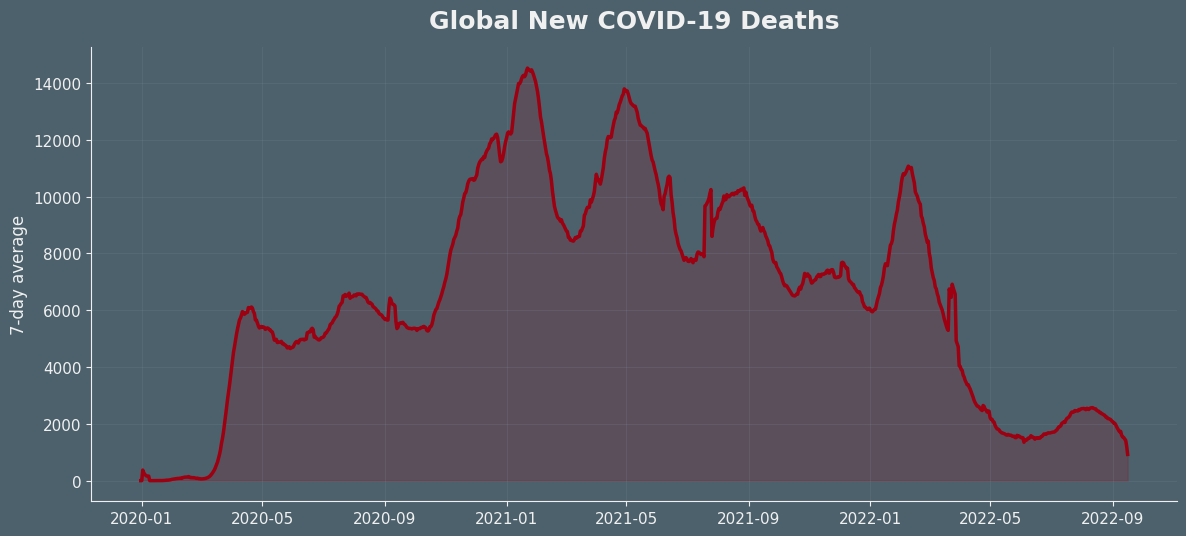

In [84]:
global_deaths = (
    epi_country.groupby("date")["new_deceased"]
    .sum()
    .rolling(7, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(global_deaths.index, global_deaths.values, color=RED, linewidth=2.5)
ax.fill_between(global_deaths.index, global_deaths.values, color=RED, alpha=0.18)

ax.set_title("Global New COVID-19 Deaths", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Average global government stringency over time

This figure shows the average Oxford government stringency index across countries over time.

The stringency index summarizes policy responses such as:
- school closures,
- workplace closures,
- gathering restrictions,
- stay-at-home requirements,
- and travel controls.

This gives a global overview of how restrictive government responses were on average during different phases of the pandemic.

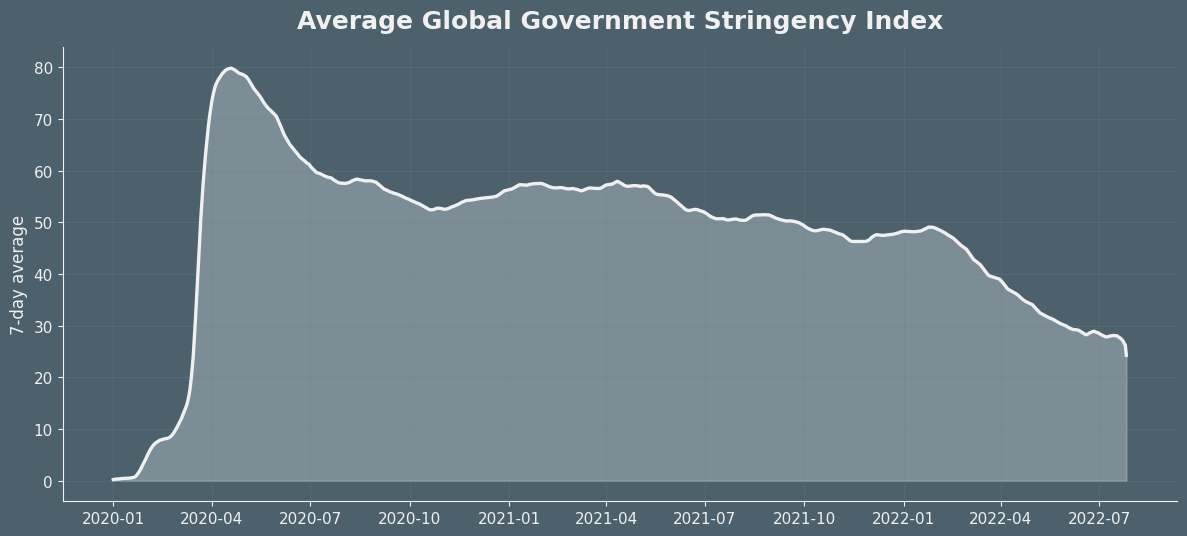

In [85]:
global_stringency = (
    gov_country.groupby("date")["stringency_index"]
    .mean()
    .rolling(7, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(global_stringency.index, global_stringency.values, color=TEXT, linewidth=2.4)
ax.fill_between(global_stringency.index, global_stringency.values, color=LIGHT_FILL, alpha=0.35)

ax.set_title("Average Global Government Stringency Index", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Summary totals from the epidemiology dataset

We calculate dataset-wide summary values using the latest country-level cumulative totals:

- total confirmed infections,
- total deaths,
- total recovered,
- and number of affected countries.

Because the dataset includes multiple dates, we first take the **latest cumulative row for each country**.

In [86]:
latest_totals = (
    epi_country.sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[
        ["cumulative_confirmed", "cumulative_deceased", "cumulative_recovered"]
    ]
    .last()
    .fillna(0)
)

total_infected = latest_totals["cumulative_confirmed"].sum()
total_deaths = latest_totals["cumulative_deceased"].sum()
total_recovered = latest_totals["cumulative_recovered"].sum()
countries_affected = (latest_totals["cumulative_confirmed"] > 0).sum()

print("Total infected:", f"{int(total_infected):,}")
print("Total countries affected:", f"{int(countries_affected):,}")
print("Total deaths:", f"{int(total_deaths):,}")
print("Total recovered:", f"{int(total_recovered):,}")

Total infected: 606,525,388
Total countries affected: 227
Total deaths: 6,167,100
Total recovered: 327,308,101


## World map of total infections

This choropleth map shows total confirmed COVID-19 infections by country.

Important notes:
- only country-level rows are used,
- ISO-2 country codes are converted to ISO-3,
- and the color range is slightly clipped at the upper end to improve contrast among mid-sized countries.

Countries with zero infections are shown in light gray, while countries with nonzero infections are shown in shades of red.

In [87]:
BG_DARK = "#4C4153"
LAND_LIGHT = "#F0F0F0"
TEXT_LIGHT = "#F0F0F0"
BORDER_SOFT = "#D9E0E4"

color_scale_red_modern = [
    [0.00, "#F3C7CC"],
    [0.20, "#E99AA3"],
    [0.40, "#DB6672"],
    [0.60, "#C92F3C"],
    [0.80, "#9D0011"],
    [1.00, "#2A0004"],
]

latest_cases = (
    epi_country.sort_values("date")
    .groupby("location_key", as_index=False)["cumulative_confirmed"]
    .last()
    .copy()
)

latest_cases["iso3"] = latest_cases["location_key"].apply(iso2_to_iso3)
latest_cases["cumulative_confirmed"] = latest_cases["cumulative_confirmed"].fillna(0)

zero_cases = latest_cases[latest_cases["cumulative_confirmed"] == 0].copy()
nonzero_cases = latest_cases[latest_cases["cumulative_confirmed"] > 0].copy()

nonzero_cases["log_cases"] = np.log10(nonzero_cases["cumulative_confirmed"] + 1)

zmin = nonzero_cases["log_cases"].min()
zmax = nonzero_cases["log_cases"].quantile(0.98)

fig = px.choropleth(
    nonzero_cases,
    locations="iso3",
    color="log_cases",
    hover_name="location_key",
    color_continuous_scale=color_scale_red_modern,
    projection="natural earth",
    title="World Map: Total COVID-19 Infections by Country",
    range_color=(zmin, zmax),
)

if len(zero_cases) > 0:
    fig.add_choropleth(
        locations=zero_cases["iso3"],
        z=[0] * len(zero_cases),
        colorscale=[[0, LAND_LIGHT], [1, LAND_LIGHT]],
        showscale=False,
        hovertext=zero_cases["location_key"],
        hoverinfo="text",
        marker_line_color=BORDER_SOFT,
        marker_line_width=0.6,
    )

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT, size=14),
    title=dict(
        text="World Map: Total COVID-19 Infections by Country",
        x=0.03,
        xanchor="left",
        font=dict(size=30, color=TEXT_LIGHT)
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text="log10(infections + 1)",
            font=dict(color=TEXT_LIGHT)
        ),
        tickfont=dict(color=TEXT_LIGHT),
        thickness=20,
        len=0.80
    ),
    margin=dict(l=0, r=0, t=70, b=0),
)

fig.update_geos(
    showframe=False,
    showcoastlines=False,
    showcountries=True,
    countrycolor=BORDER_SOFT,
    countrywidth=0.6,
    showland=True,
    landcolor=LAND_LIGHT,
    showocean=True,
    oceancolor=BG_DARK,
    bgcolor=BG_DARK,
)
fig.write_html("total_infections_world.html", include_plotlyjs='cdn')

fig.show()

## World map of total deaths

This map uses the same visual style as the infections map, but colors countries by total COVID-19 deaths instead of total confirmed infections.

This allows us to compare spread and mortality side by side.

In [88]:
latest_deaths = (
    epi_country.sort_values("date")
    .groupby("location_key", as_index=False)["cumulative_deceased"]
    .last()
    .copy()
)

latest_deaths["iso3"] = latest_deaths["location_key"].apply(iso2_to_iso3)
latest_deaths["cumulative_deceased"] = latest_deaths["cumulative_deceased"].fillna(0)

zero_deaths = latest_deaths[latest_deaths["cumulative_deceased"] == 0].copy()
nonzero_deaths = latest_deaths[latest_deaths["cumulative_deceased"] > 0].copy()

nonzero_deaths["log_deaths"] = np.log10(nonzero_deaths["cumulative_deceased"] + 1)

zmin = nonzero_deaths["log_deaths"].min()
zmax = nonzero_deaths["log_deaths"].quantile(0.98)

fig = px.choropleth(
    nonzero_deaths,
    locations="iso3",
    color="log_deaths",
    hover_name="location_key",
    color_continuous_scale=color_scale_red_modern,
    projection="natural earth",
    title="World Map: Total COVID-19 Deaths by Country",
    range_color=(zmin, zmax),
)

if len(zero_deaths) > 0:
    fig.add_choropleth(
        locations=zero_deaths["iso3"],
        z=[0] * len(zero_deaths),
        colorscale=[[0, LAND_LIGHT], [1, LAND_LIGHT]],
        showscale=False,
        hovertext=zero_deaths["location_key"],
        hoverinfo="text",
        marker_line_color=BORDER_SOFT,
        marker_line_width=0.6,
    )

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT, size=14),
    title=dict(
        text="World Map: Total COVID-19 Deaths by Country",
        x=0.03,
        xanchor="left",
        font=dict(size=30, color=TEXT_LIGHT)
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text="log10(deaths + 1)",
            font=dict(color=TEXT_LIGHT)
        ),
        tickfont=dict(color=TEXT_LIGHT),
        thickness=20,
        len=0.80
    ),
    margin=dict(l=0, r=0, t=70, b=0),
)

fig.update_geos(
    showframe=False,
    showcoastlines=False,
    showcountries=True,
    countrycolor=BORDER_SOFT,
    countrywidth=0.6,
    showland=True,
    landcolor=LAND_LIGHT,
    showocean=True,
    oceancolor=BG_DARK,
    bgcolor=BG_DARK,
)
fig.write_html("total_deaths_world.html", include_plotlyjs='cdn')

fig.show()

## Selected countries for comparison

To create a more focused comparison, we now examine three European countries:

- Denmark (`DK`)
- Germany (`DE`)
- Great Britain / United Kingdom (`GB`)

These countries are geographically closer and more comparable than the earlier global set.  
This makes it easier to study differences in COVID-19 development and government response in a more controlled regional context.

In [89]:
selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

COUNTRY_COLORS = {
    "DK": "#F87CFF",
    "DE": "#77CBFF",
    "GB": "#71FEF0",
}

## Build comparison tables

We prepare cleaned country-level time series for the selected countries.

For the epidemiology data we compute:
- 7-day average confirmed cases
- 7-day average deaths

For the Oxford dataset we compute:
- 7-day average stringency index

These smoothed measures reduce day-to-day reporting noise and make country comparisons easier to interpret.

In [90]:
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["new_deceased_7d"] = (
    epi_compare.groupby("location_key")["new_deceased"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

gov_compare["stringency_7d"] = (
    gov_compare.groupby("location_key")["stringency_index"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["country"] = epi_compare["location_key"].map(country_names)
gov_compare["country"] = gov_compare["location_key"].map(country_names)

print(epi_compare.shape)
print(gov_compare.shape)

(2961, 13)
(2787, 24)


## Static comparison: new confirmed cases

This figure compares Denmark, Germany, and Great Britain using 7-day average confirmed cases.

Because all three countries are shown in the same figure, direct comparison is possible across:
- timing of waves,
- height of peaks,
- and overall development over time.

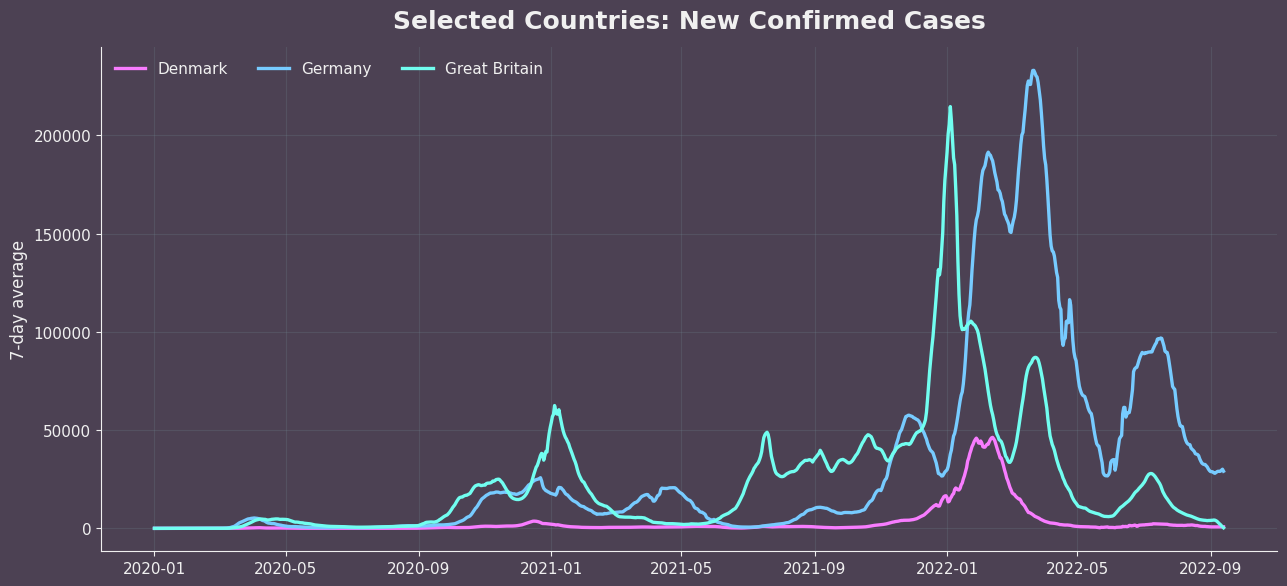

In [91]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#4c4153')
ax.set_facecolor('#4c4153')

for code in selected_countries:
    df_plot = epi_compare[epi_compare["location_key"] == code]
    ax.plot(
        df_plot["date"],
        df_plot["new_confirmed_7d"],
        label=country_names[code],
        linewidth=2.4,
        color=COUNTRY_COLORS[code]
    )

ax.set_title("Selected Countries: New Confirmed Cases", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")
ax.legend(frameon=False, ncol=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Static comparison: new deaths

This figure compares Denmark, Germany, and Great Britain using 7-day average COVID-19 deaths.

This is useful for comparing pandemic severity and the timing of death waves across the three countries.

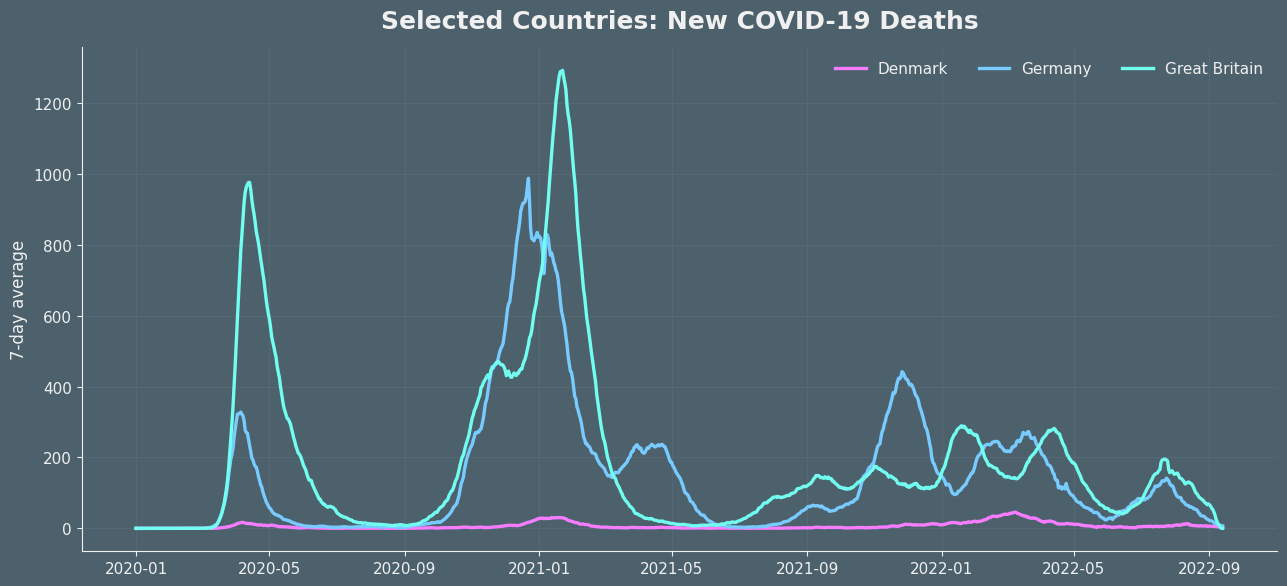

In [92]:
fig, ax = plt.subplots(figsize=(13, 6))

for code in selected_countries:
    df_plot = epi_compare[epi_compare["location_key"] == code]
    ax.plot(
        df_plot["date"],
        df_plot["new_deceased_7d"],
        label=country_names[code],
        linewidth=2.4,
        color=COUNTRY_COLORS[code]
    )

ax.set_title("Selected Countries: New COVID-19 Deaths", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")
ax.legend(frameon=False, ncol=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Static comparison: government stringency

This figure compares the Oxford government stringency index across Denmark, Germany, and Great Britain.

The chart helps identify differences in:
- timing of restrictions,
- intensity of responses,
- and how long strict measures remained in place.

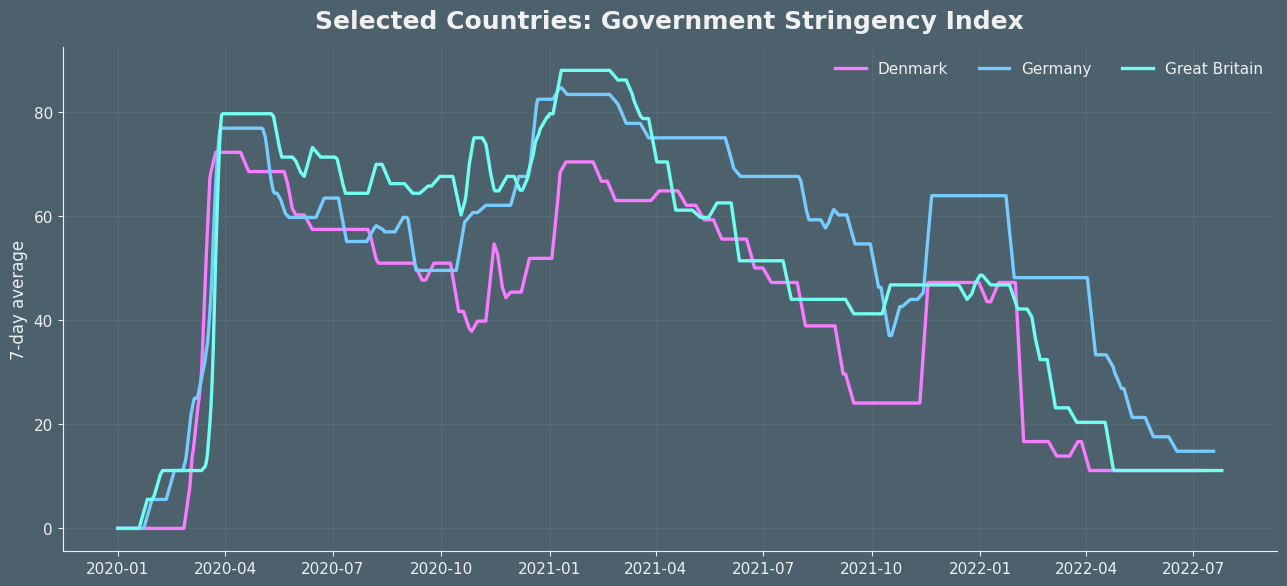

In [93]:
fig, ax = plt.subplots(figsize=(13, 6))

for code in selected_countries:
    df_plot = gov_compare[gov_compare["location_key"] == code]
    ax.plot(
        df_plot["date"],
        df_plot["stringency_7d"],
        label=country_names[code],
        linewidth=2.4,
        color=COUNTRY_COLORS[code]
    )

ax.set_title("Selected Countries: Government Stringency Index", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")
ax.legend(frameon=False, ncol=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Small multiples: cases by country

This figure shows each country in its own panel, while keeping the **same x-axis and y-axis scale across all panels**.

This is important because it allows fair comparison without visually exaggerating smaller or larger countries.

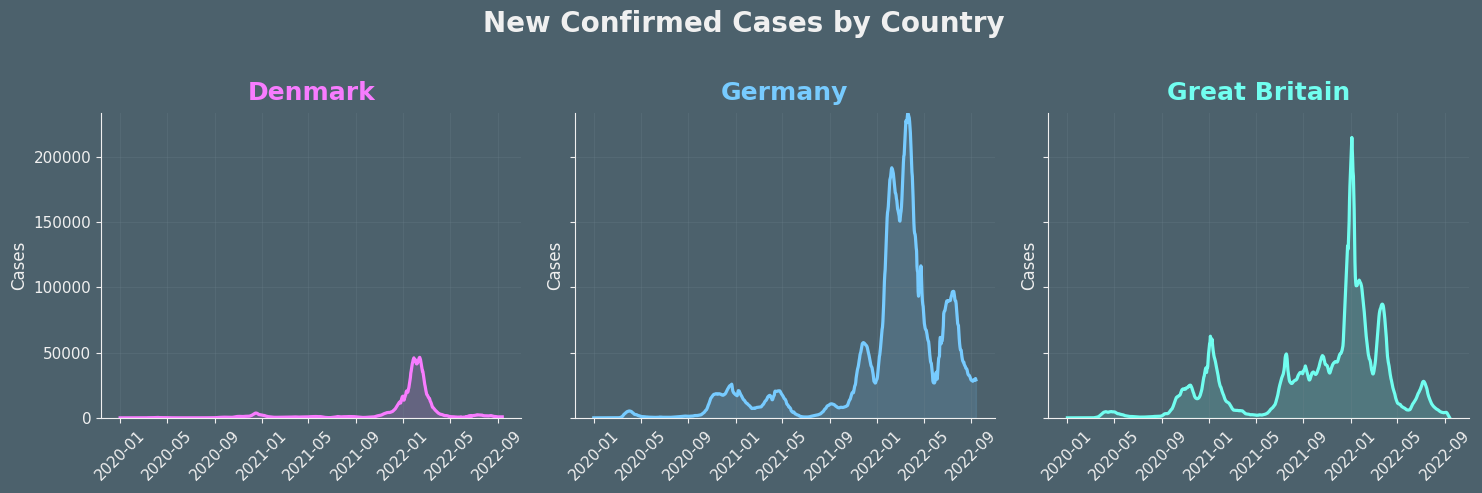

In [94]:
# Shared y-axis maximum for fair comparison
cases_ymax = epi_compare["new_confirmed_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = epi_compare[epi_compare["location_key"] == code]
    c = COUNTRY_COLORS[code]

    ax.plot(df_plot["date"], df_plot["new_confirmed_7d"], color=c, linewidth=2.3)
    ax.fill_between(df_plot["date"], df_plot["new_confirmed_7d"], color=c, alpha=0.14)

    ax.set_title(country_names[code], color=c, pad=10)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, cases_ymax)
    ax.set_ylabel("Cases")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("New Confirmed Cases by Country", fontsize=20, fontweight="bold", y=1.02, color=TEXT)
plt.tight_layout()
plt.show()

## Small multiples: deaths by country

Each country is shown in its own panel, again with **shared x-axis and y-axis scales**.

This makes it possible to compare the relative size and timing of death waves fairly.

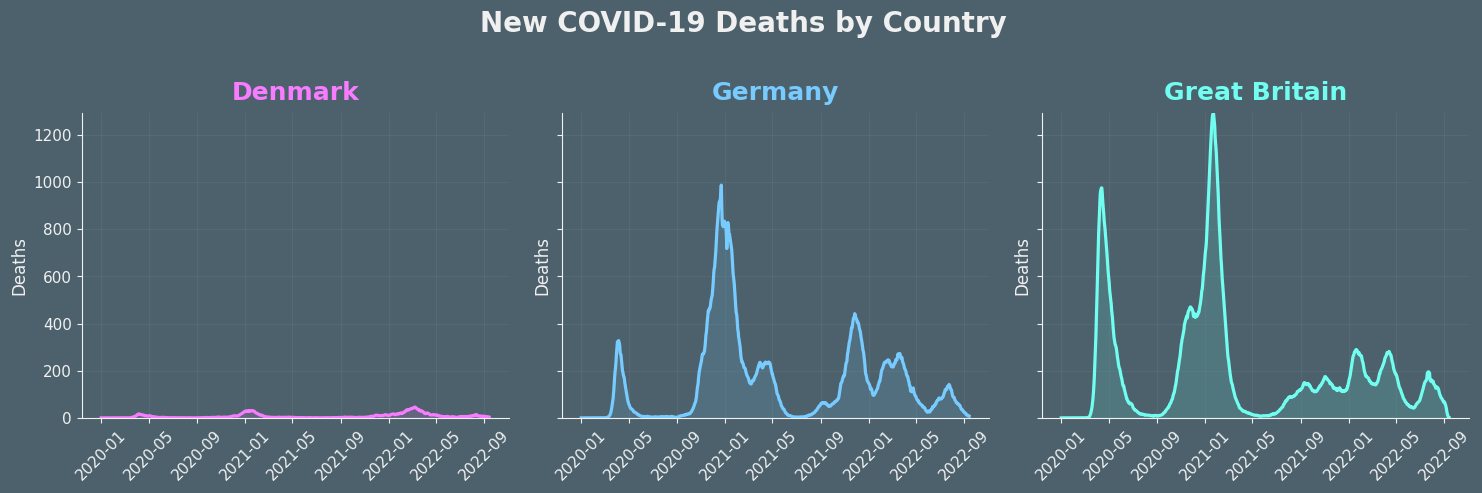

In [95]:
deaths_ymax = epi_compare["new_deceased_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = epi_compare[epi_compare["location_key"] == code]
    c = COUNTRY_COLORS[code]

    ax.plot(df_plot["date"], df_plot["new_deceased_7d"], color=c, linewidth=2.3)
    ax.fill_between(df_plot["date"], df_plot["new_deceased_7d"], color=c, alpha=0.14)

    ax.set_title(country_names[code], color=c, pad=10)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, deaths_ymax)
    ax.set_ylabel("Deaths")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("New COVID-19 Deaths by Country", fontsize=20, fontweight="bold", y=1.02, color=TEXT)
plt.tight_layout()
plt.show()

## Small multiples: government stringency by country

This figure shows each country's government stringency separately, but using the same axis scale across panels.

Because the Oxford stringency index is bounded, comparable scales are especially important for correct interpretation.

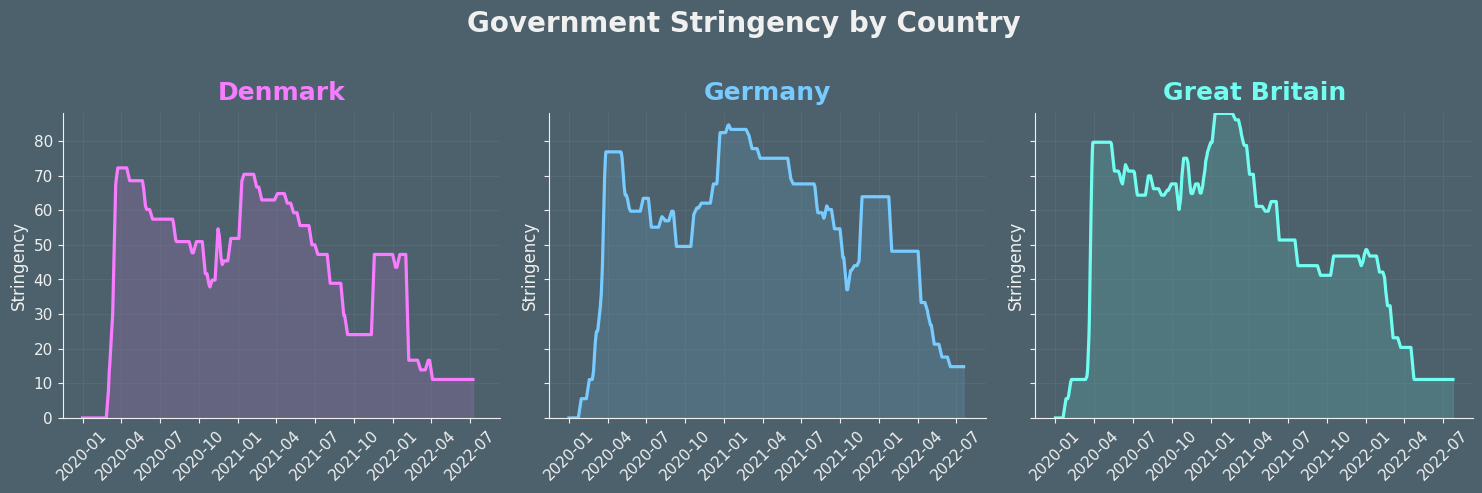

In [96]:
stringency_ymax = gov_compare["stringency_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = gov_compare[gov_compare["location_key"] == code]
    c = COUNTRY_COLORS[code]

    ax.plot(df_plot["date"], df_plot["stringency_7d"], color=c, linewidth=2.3)
    ax.fill_between(df_plot["date"], df_plot["stringency_7d"], color=c, alpha=0.14)

    ax.set_title(country_names[code], color=c, pad=10)
    ax.tick_params(axis='x', labelrotation=45)    
    ax.set_ylim(0, stringency_ymax)
    ax.set_ylabel("Stringency")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Government Stringency by Country", fontsize=20, fontweight="bold", y=1.02, color=TEXT)
plt.tight_layout()
plt.show()

## Cases and government response by country

Each panel shows:
- new confirmed cases on the left axis,
- government stringency on the right axis.

The **left axis is shared across all countries**, which makes the case comparison fair.
The **right axis is also shared**, which keeps stringency directly comparable.

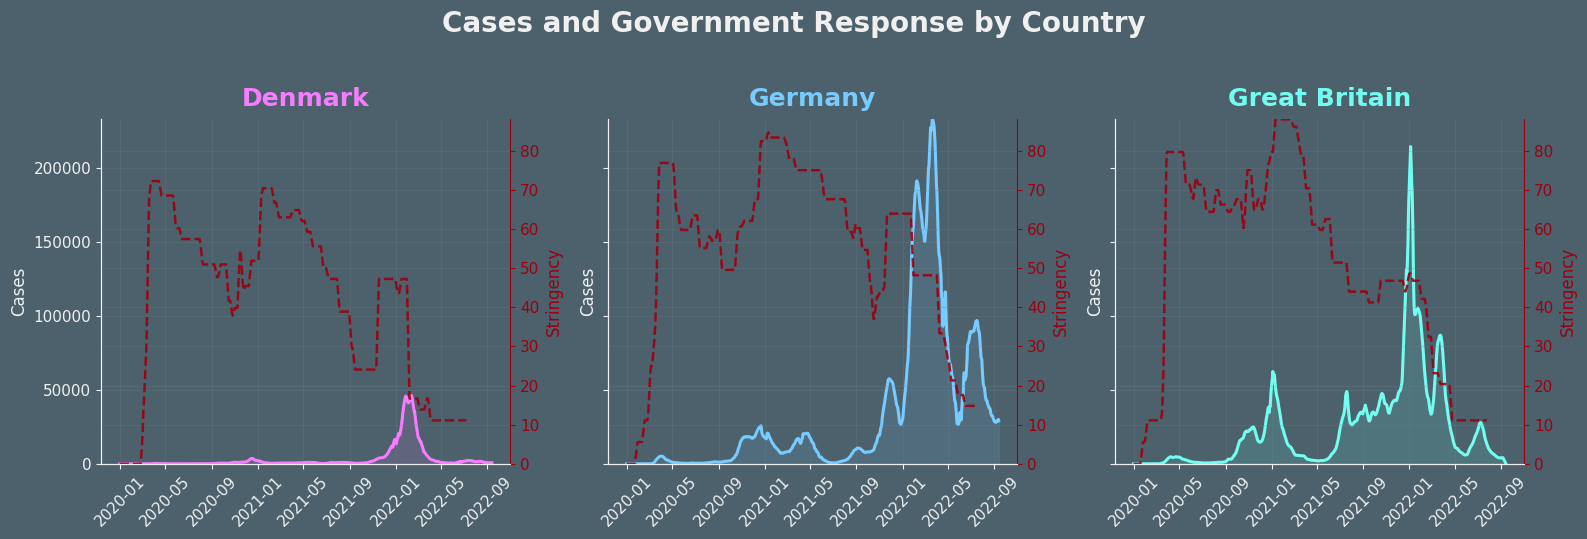

In [97]:
cases_ymax = epi_compare["new_confirmed_7d"].max()
stringency_ymax = gov_compare["stringency_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    epi_plot = epi_compare[epi_compare["location_key"] == code].sort_values("date")
    gov_plot = gov_compare[gov_compare["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax.plot(epi_plot["date"], epi_plot["new_confirmed_7d"], color=c, linewidth=2.2)
    ax.fill_between(epi_plot["date"], epi_plot["new_confirmed_7d"], color=c, alpha=0.12)
    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylabel("Cases")
    ax.set_ylim(0, cases_ymax)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax2 = ax.twinx()
    ax2.plot(gov_plot["date"], gov_plot["stringency_7d"], color=RED, linestyle="--", linewidth=1.8, alpha=0.9)
    ax.tick_params(axis='x', labelrotation=45)
    ax2.set_ylim(0, stringency_ymax)
    ax2.set_ylabel("Stringency", color=RED)
    ax2.tick_params(axis="y", colors=RED)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(RED)

fig.suptitle("Cases and Government Response by Country", fontsize=20, fontweight="bold", y=1.03, color=TEXT)
plt.tight_layout()
plt.show()

## Interactive comparison: cases over time

This interactive figure allows the user to:
- zoom into specific periods,
- toggle countries on and off,
- and inspect exact values by hovering.

This is especially useful for identifying the timing and size of different waves.

In [98]:
import plotly.express as px

fig = px.line(
    epi_compare,
    x="date",
    y="new_confirmed_7d",
    color="country",
    color_discrete_map={
        "Denmark": "#AEBCC3",
        "Germany": "#202983",
        "Great Britain": "#9D0011",
    },
    title="Interactive Comparison: New Confirmed Cases",
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="",
    yaxis_title="7-day average",
    legend_title="Country",
    hovermode="x unified"
)

fig.update_xaxes(showgrid=True, gridcolor="#6F838D")
fig.update_yaxes(showgrid=True, gridcolor="#6F838D")

fig.show()

## Interactive comparison: deaths over time

This chart supports interactive comparison of death patterns across Denmark, Germany, and Great Britain.

In [99]:
fig = px.line(
    gov_compare,
    x="date",
    y="stringency_7d",
    color="country",
    color_discrete_map={
        "Denmark": "#AEBCC3",
        "Germany": "#202983",
        "Great Britain": "#9D0011",
    },
    title="Interactive Comparison: Government Stringency",
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="",
    yaxis_title="7-day average",
    legend_title="Country",
    hovermode="x unified"
)

fig.update_xaxes(showgrid=True, gridcolor="#6F838D")
fig.update_yaxes(showgrid=True, gridcolor="#6F838D")

fig.show()

## Interactive cases comparison with date range controls

This version adds a date range slider and range selector buttons so the user can quickly focus on shorter phases of the pandemic, such as 6 months or 1 year.

In [100]:
import plotly.graph_objects as go

fig = go.Figure()

for code in selected_countries:
    df_country = epi_compare[epi_compare["location_key"] == code]
    fig.add_trace(
        go.Scatter(
            x=df_country["date"],
            y=df_country["new_confirmed_7d"],
            mode="lines",
            name=country_names[code],
            line=dict(color=COUNTRY_COLORS[code], width=2.5),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Date: %{x|%Y-%m-%d}<br>"
                "Cases: %{y:,.0f}<extra></extra>"
            )
        )
    )

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title="Interactive Cases Comparison with Date Range Controls",
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="",
    yaxis_title="7-day average cases",
    hovermode="x unified",
    legend_title="Country"
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#6F838D",
    rangeslider_visible=True,
    rangeselector=dict(
        bgcolor="#F0F0F0",
        activecolor="#9D0011",
        buttons=list([
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=2, label="2y", step="year", stepmode="backward"),
            dict(step="all", label="All")
        ])
    )
)

fig.update_yaxes(showgrid=True, gridcolor="#6F838D")

fig.show()

## Interactive comparison with year and metric controls

This figure allows the user to switch between:
- cases
- deaths

and between available years.

It is useful for focusing on specific pandemic phases and comparing how the three countries behaved within the same time window.

In [101]:
plot_df = epi_compare[["date", "location_key", "country", "new_confirmed_7d", "new_deceased_7d"]].copy()
plot_df["year"] = plot_df["date"].dt.year

available_years = sorted(plot_df["year"].dropna().unique())

fig = go.Figure()

trace_lookup = []
for metric_name, metric_col in [("Cases", "new_confirmed_7d"), ("Deaths", "new_deceased_7d")]:
    for year in available_years:
        df_year = plot_df[plot_df["year"] == year]
        for code in selected_countries:
            df_country = df_year[df_year["location_key"] == code]
            fig.add_trace(
                go.Scatter(
                    x=df_country["date"],
                    y=df_country[metric_col],
                    mode="lines",
                    name=country_names[code],
                    line=dict(color=COUNTRY_COLORS[code], width=2.5),
                    visible=(metric_name == "Cases" and year == available_years[0]),
                    hovertemplate=(
                        "<b>%{fullData.name}</b><br>"
                        "Date: %{x|%Y-%m-%d}<br>"
                        f"{metric_name}: " + "%{y:,.0f}<extra></extra>"
                    )
                )
            )
            trace_lookup.append((metric_name, year, code))

def visibility_mask(metric, year):
    return [(m == metric and y == year) for (m, y, c) in trace_lookup]

metric_year_buttons = []
for metric_name, y_title in [("Cases", "7-day average cases"), ("Deaths", "7-day average deaths")]:
    for year in available_years:
        metric_year_buttons.append(
            dict(
                label=f"{metric_name} — {year}",
                method="update",
                args=[
                    {"visible": visibility_mask(metric_name, year)},
                    {
                        "title": f"Interactive Country Comparison — {metric_name} in {year}",
                        "yaxis": {"title": y_title}
                    }
                ]
            )
        )

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title=f"Interactive Country Comparison — Cases in {available_years[0]}",
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="",
    yaxis_title="7-day average cases",
    hovermode="x unified",
    legend_title="Country",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=1.02,
            y=1.00,
            showactive=True,
            buttons=metric_year_buttons
        )
    ]
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#6F838D",
    rangeslider_visible=True
)
fig.update_yaxes(showgrid=True, gridcolor="#6F838D")

fig.show()

## Monthly aggregation for heatmaps

To compare the three countries over time more clearly, we aggregate daily data to the monthly level.

For each country and month, we compute:
- average monthly cases,
- average monthly deaths,
- average monthly government stringency.

In [102]:
epi_monthly = epi_compare.copy()
epi_monthly["year"] = epi_monthly["date"].dt.year
epi_monthly["month"] = epi_monthly["date"].dt.month
epi_monthly["month_name"] = epi_monthly["date"].dt.strftime("%b")

epi_monthly_agg = (
    epi_monthly.groupby(["location_key", "country", "year", "month", "month_name"], as_index=False)
    .agg(
        avg_cases=("new_confirmed_7d", "mean"),
        avg_deaths=("new_deceased_7d", "mean")
    )
)

gov_monthly = gov_compare.copy()
gov_monthly["year"] = gov_monthly["date"].dt.year
gov_monthly["month"] = gov_monthly["date"].dt.month
gov_monthly["month_name"] = gov_monthly["date"].dt.strftime("%b")

gov_monthly_agg = (
    gov_monthly.groupby(["location_key", "country", "year", "month", "month_name"], as_index=False)
    .agg(
        avg_stringency=("stringency_7d", "mean")
    )
)

print(epi_monthly_agg.head())
print(gov_monthly_agg.head())

  location_key  country  year  month month_name    avg_cases  avg_deaths
0           DE  Germany  2020      1        Jan     0.212673    0.000000
1           DE  Germany  2020      2        Feb     2.704433    0.034483
2           DE  Germany  2020      3        Mar  2086.041475   68.769585
3           DE  Germany  2020      4        Apr  3157.057143  205.219048
4           DE  Germany  2020      5        May   703.483871   26.640553
  location_key  country  year  month month_name  avg_stringency
0           DE  Germany  2020      1        Jan        0.896774
1           DE  Germany  2020      2        Feb        8.772906
2           DE  Germany  2020      3        Mar       43.167926
3           DE  Germany  2020      4        Apr       76.850000
4           DE  Germany  2020      5        May       65.499677


## Heatmap: cases by country and month

This heatmap shows average monthly cases for Denmark, Germany, and Great Britain.

Viewing one year at a time makes it easier to compare the timing and intensity of waves across countries.

In [103]:
year_to_plot = 2021

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_cases["month_name"] = pd.Categorical(heat_cases["month_name"], categories=month_order, ordered=True)
heat_cases = heat_cases.sort_values(["country", "month"])

fig = px.density_heatmap(
    heat_cases,
    x="month_name",
    y="country",
    z="avg_cases",
    histfunc="avg",
    color_continuous_scale=[
        [0.0, "#F3C7CC"],
        [0.20, "#E99AA3"],
        [0.40, "#DB6672"],
        [0.60, "#C92F3C"],
        [0.80, "#9D0011"],
        [1.00, "#2A0004"],
    ],
    title=f"Monthly COVID-19 Cases by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(text="Average cases", font=dict(color="#F0F0F0")),
        tickfont=dict(color="#F0F0F0")
    )
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

## Heatmap: deaths by country and month

This heatmap shows average monthly deaths for Denmark, Germany, and Great Britain.

In [104]:
year_to_plot = 2021

heat_deaths = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_deaths["month_name"] = pd.Categorical(heat_deaths["month_name"], categories=month_order, ordered=True)
heat_deaths = heat_deaths.sort_values(["country", "month"])

fig = px.density_heatmap(
    heat_deaths,
    x="month_name",
    y="country",
    z="avg_deaths",
    histfunc="avg",
    color_continuous_scale=[
        [0.0, "#F3C7CC"],
        [0.20, "#E99AA3"],
        [0.40, "#DB6672"],
        [0.60, "#C92F3C"],
        [0.80, "#9D0011"],
        [1.00, "#2A0004"],
    ],
    title=f"Monthly COVID-19 Deaths by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(text="Average deaths", font=dict(color="#F0F0F0")),
        tickfont=dict(color="#F0F0F0")
    )
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

## Heatmap: government stringency by country and month

This heatmap shows average monthly government stringency for Denmark, Germany, and Great Britain.

In [105]:
year_to_plot = 2021

heat_stringency = gov_monthly_agg[gov_monthly_agg["year"] == year_to_plot].copy()
heat_stringency["month_name"] = pd.Categorical(heat_stringency["month_name"], categories=month_order, ordered=True)
heat_stringency = heat_stringency.sort_values(["country", "month"])

fig = px.density_heatmap(
    heat_stringency,
    x="month_name",
    y="country",
    z="avg_stringency",
    histfunc="avg",
    color_continuous_scale=[
        [0.0, "#DCE4E8"],
        [0.25, "#B8C7CE"],
        [0.50, "#8FA5AF"],
        [0.75, "#667F8A"],
        [1.00, "#202983"],
    ],
    title=f"Monthly Government Stringency by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(text="Average stringency", font=dict(color="#F0F0F0")),
        tickfont=dict(color="#F0F0F0")
    )
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

## Interactive heatmap with year dropdown

This figure allows the user to switch between years and compare monthly cases across Denmark, Germany, and Great Britain.

In [106]:
fig = go.Figure()

heat_years = sorted(epi_monthly_agg["year"].dropna().unique())
trace_info = []

for year in heat_years:
    heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year].copy()
    heat_cases["month_name"] = pd.Categorical(heat_cases["month_name"], categories=month_order, ordered=True)
    heat_cases = heat_cases.sort_values(["country", "month"])

    pivot_df = heat_cases.pivot(index="country", columns="month_name", values="avg_cases").reindex(columns=month_order)

    fig.add_trace(
        go.Heatmap(
            z=pivot_df.values,
            x=pivot_df.columns,
            y=pivot_df.index,
            colorscale=[
                [0.0, "#F3C7CC"],
                [0.20, "#E99AA3"],
                [0.40, "#DB6672"],
                [0.60, "#C92F3C"],
                [0.80, "#9D0011"],
                [1.00, "#2A0004"],
            ],
            visible=(year == heat_years[0]),
            colorbar=dict(title="Avg cases")
        )
    )
    trace_info.append(year)

buttons = []
for year in heat_years:
    buttons.append(
        dict(
            label=str(year),
            method="update",
            args=[
                {"visible": [y == year for y in trace_info]},
                {"title": f"Monthly COVID-19 Cases by Country — {year}"}
            ]
        )
    )

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title=f"Monthly COVID-19 Cases by Country — {heat_years[0]}",
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="Month",
    yaxis_title="Country",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=1.02,
            y=1.00,
            showactive=True,
            buttons=buttons
        )
    ]
)

fig.show()

## Population-adjusted comparison: cases and government response

To compare Denmark, Germany, and Great Britain fairly, we normalize case counts by population size.

Instead of plotting raw confirmed cases, we plot:

- **new confirmed cases per 100,000 people**
- **government stringency index**

This makes the case curves more comparable across countries with different population sizes.

In this figure:
- the **left axis** shows 7-day average new confirmed cases per 100,000 people,
- the **right axis** shows the Oxford government stringency index,
- and all country panels use the **same x-axis and y-axis scales** to ensure fair visual comparison.

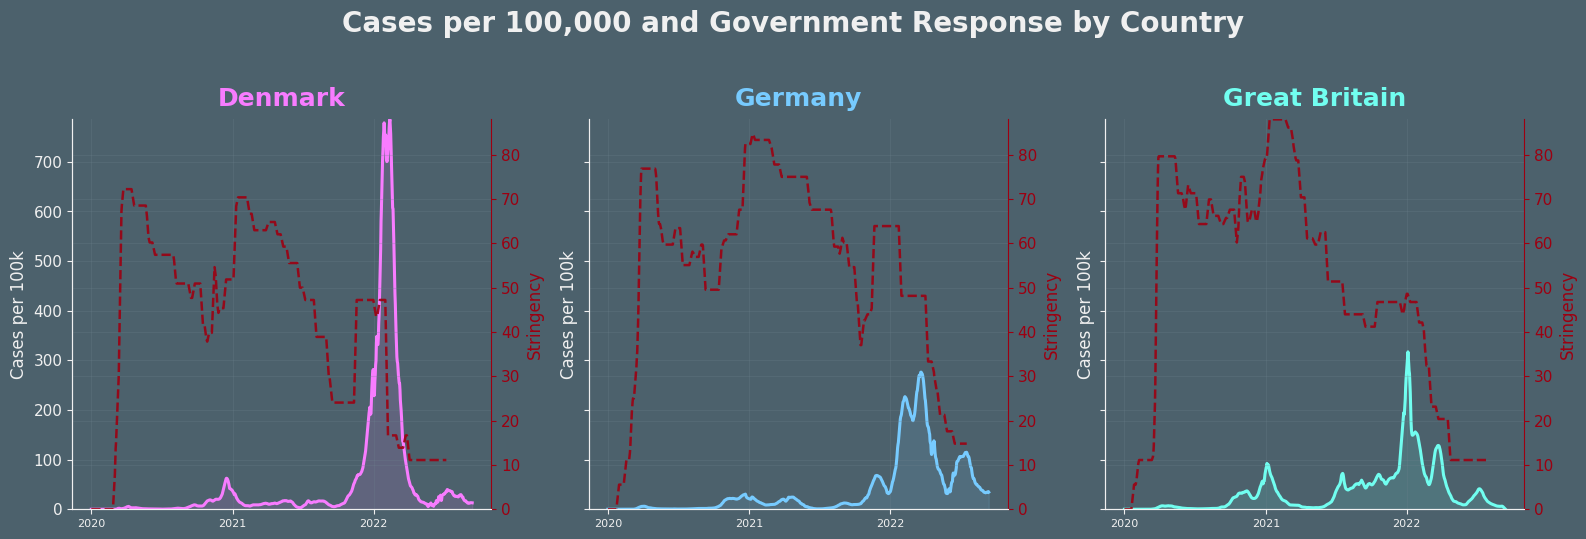

In [107]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --------------------------------------------------
# Population values
# Replace these with the exact source/year you want to use
# --------------------------------------------------
population_map = {
    "DK": 5900000,    # Denmark
    "DE": 84400000,   # Germany
    "GB": 67700000,   # Great Britain / United Kingdom
}

# --------------------------------------------------
# Build a population-adjusted epidemiology table
# --------------------------------------------------
epi_compare_pop = epi_compare.copy()
epi_compare_pop["population"] = epi_compare_pop["location_key"].map(population_map)

# Cases per 100,000 people
epi_compare_pop["cases_per_100k_7d"] = (
    epi_compare_pop["new_confirmed_7d"] / epi_compare_pop["population"] * 100000
)

# Optional: deaths per 100,000 too, if you want later
epi_compare_pop["deaths_per_100k_7d"] = (
    epi_compare_pop["new_deceased_7d"] / epi_compare_pop["population"] * 100000
)

# --------------------------------------------------
# Shared axis limits for fair comparison
# --------------------------------------------------
cases_per_100k_ymax = epi_compare_pop["cases_per_100k_7d"].max()
stringency_ymax = gov_compare["stringency_7d"].max()

# --------------------------------------------------
# Plot: cases per 100k + stringency
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    epi_plot = (
        epi_compare_pop[epi_compare_pop["location_key"] == code]
        .sort_values("date")
        .copy()
    )
    gov_plot = (
        gov_compare[gov_compare["location_key"] == code]
        .sort_values("date")
        .copy()
    )

    c = COUNTRY_COLORS[code]

    # Left axis: cases per 100k
    ax.plot(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        linewidth=2.2
    )
    ax.fill_between(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylabel("Cases per 100k")
    ax.set_ylim(0, cases_per_100k_ymax)

    # Cleaner axis styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Use year ticks only and smaller font
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=8)

    # Right axis: stringency
    ax2 = ax.twinx()
    ax2.plot(
        gov_plot["date"],
        gov_plot["stringency_7d"],
        color=RED,
        linestyle="--",
        linewidth=1.8,
        alpha=0.9
    )
    ax2.set_ylim(0, stringency_ymax)
    ax2.set_ylabel("Stringency", color=RED)
    ax2.tick_params(axis="y", colors=RED)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(RED)

fig.suptitle(
    "Cases per 100,000 and Government Response by Country",
    fontsize=20,
    fontweight="bold",
    y=1.03,
    color=TEXT
)

plt.tight_layout()
plt.show()

## Population-adjusted comparison: deaths and government response

To compare Denmark, Germany, and Great Britain fairly, we normalize death counts by population size.

Instead of plotting raw COVID-19 deaths, we plot:

- **new deaths per 100,000 people**
- **government stringency index**

This makes the death curves comparable across countries with different population sizes.

In this figure:
- the **left axis** shows 7-day average new deaths per 100,000 people,
- the **right axis** shows the Oxford government stringency index,
- and all country panels use the **same x-axis and y-axis scales** to ensure fair visual comparison.

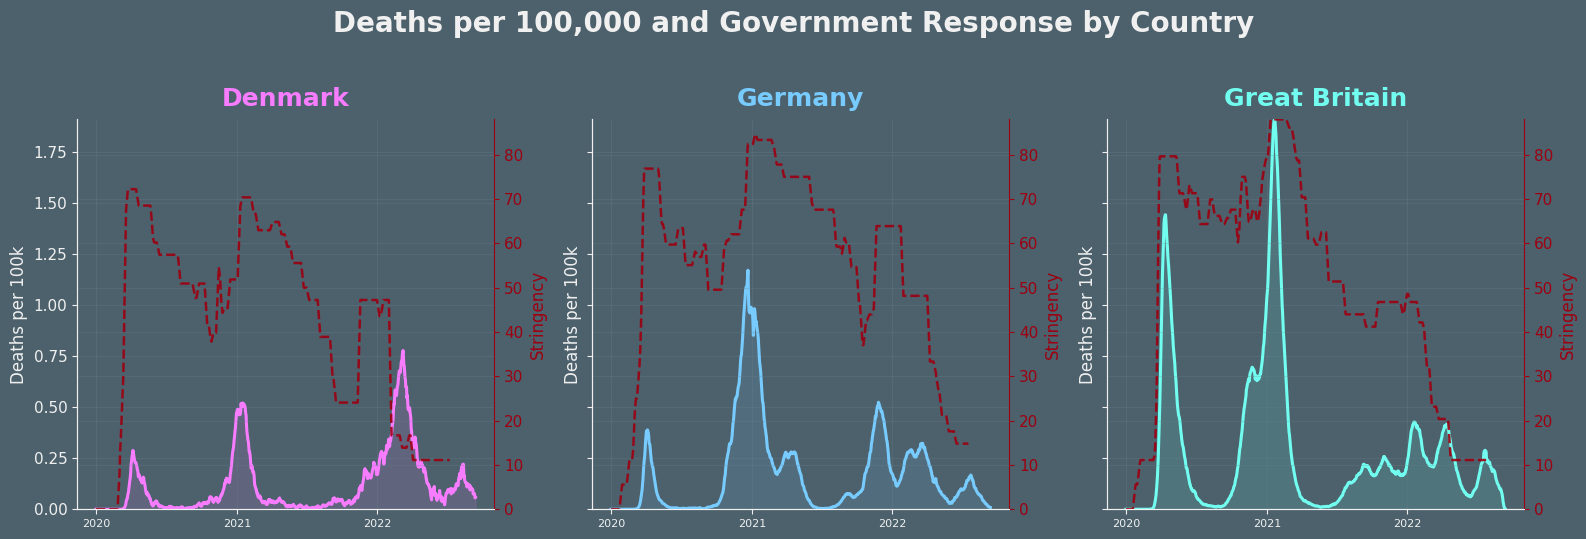

In [108]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --------------------------------------------------
# Population values
# Replace these with the exact source/year you want to use
# --------------------------------------------------
population_map = {
    "DK": 5900000,    # Denmark
    "DE": 84400000,   # Germany
    "GB": 67700000,   # Great Britain / United Kingdom
}

# --------------------------------------------------
# Build a population-adjusted epidemiology table
# --------------------------------------------------
epi_compare_pop = epi_compare.copy()
epi_compare_pop["population"] = epi_compare_pop["location_key"].map(population_map)

# Deaths per 100,000 people
epi_compare_pop["deaths_per_100k_7d"] = (
    epi_compare_pop["new_deceased_7d"] / epi_compare_pop["population"] * 100000
)

# --------------------------------------------------
# Shared axis limits for fair comparison
# --------------------------------------------------
deaths_per_100k_ymax = epi_compare_pop["deaths_per_100k_7d"].max()
stringency_ymax = gov_compare["stringency_7d"].max()

# --------------------------------------------------
# Plot: deaths per 100k + stringency
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    epi_plot = (
        epi_compare_pop[epi_compare_pop["location_key"] == code]
        .sort_values("date")
        .copy()
    )
    gov_plot = (
        gov_compare[gov_compare["location_key"] == code]
        .sort_values("date")
        .copy()
    )

    c = COUNTRY_COLORS[code]

    # Left axis: deaths per 100k
    ax.plot(
        epi_plot["date"],
        epi_plot["deaths_per_100k_7d"],
        color=c,
        linewidth=2.2
    )
    ax.fill_between(
        epi_plot["date"],
        epi_plot["deaths_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylabel("Deaths per 100k")
    ax.set_ylim(0, deaths_per_100k_ymax)

    # Cleaner axis styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Use year ticks only and smaller font
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=8)

    # Right axis: stringency
    ax2 = ax.twinx()
    ax2.plot(
        gov_plot["date"],
        gov_plot["stringency_7d"],
        color=RED,
        linestyle="--",
        linewidth=1.8,
        alpha=0.9
    )
    ax2.set_ylim(0, stringency_ymax)
    ax2.set_ylabel("Stringency", color=RED)
    ax2.tick_params(axis="y", colors=RED)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(RED)

fig.suptitle(
    "Deaths per 100,000 and Government Response by Country",
    fontsize=20,
    fontweight="bold",
    y=1.03,
    color=TEXT
)

plt.tight_layout()
plt.show()

Bar chart: total infections, deaths, and recovered per 100,000 people
This figure compares Denmark, Germany, and Great Britain using cumulative totals over the full dataset period.

To make the countries comparable despite different population sizes, all values are normalized to per 100,000 people.

The chart includes:
total confirmed infections per 100,000
total deaths per 100,000
total recovered per 100,000

This gives a compact summary of the overall pandemic burden in each country across the full study period.

Note: recovery data is less complete than confirmed case and death data, so the recovered bars should be interpreted with caution.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}


population_map = {
    "DK": 5900000,    # Denmark
    "DE": 84400000,   # Germany
    "GB": 67700000,   # Great Britain / United Kingdom
}


country_totals = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[
        ["cumulative_confirmed", "cumulative_deceased", "cumulative_recovered"]
    ]
    .last()
    .copy()
)

country_totals["country"] = country_totals["location_key"].map(country_names)
country_totals["population"] = country_totals["location_key"].map(population_map)


country_totals["confirmed_per_100k"] = (
    country_totals["cumulative_confirmed"] / country_totals["population"] * 100000
)
country_totals["deaths_per_100k"] = (
    country_totals["cumulative_deceased"] / country_totals["population"] * 100000
)
country_totals["recovered_per_100k"] = (
    country_totals["cumulative_recovered"] / country_totals["population"] * 100000
)

print(country_totals[[
    "country",
    "confirmed_per_100k",
    "deaths_per_100k",
    "recovered_per_100k"
]])

         country  confirmed_per_100k  deaths_per_100k  recovered_per_100k
0        Germany        38631.508294       176.218009                 NaN
1        Denmark        55656.033898       118.423729                 NaN
2  Great Britain        34793.162482       279.211226                 NaN


Bar chart: total infections, deaths, and recovered per 100,000 people
This figure compares Denmark, Germany, and Great Britain using cumulative totals over the full dataset period.

To make the countries comparable despite different population sizes, all values are normalized to per 100,000 people.

The chart includes:
total confirmed infections per 100,000
total deaths per 100,000
total recovered per 100,000

This gives a compact summary of the overall pandemic burden in each country across the full study period.

Note: recovery data is less complete than confirmed case and death data, so the recovered bars should be interpreted with caution.

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

--------------------------------------------------
Selected countries
--------------------------------------------------
selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

--------------------------------------------------
Population values
Replace with your final chosen source/year if needed
--------------------------------------------------
population_map = {
    "DK": 5900000,    # Denmark
    "DE": 84400000,   # Germany
    "GB": 67700000,   # Great Britain / United Kingdom
}

--------------------------------------------------
Get latest cumulative totals by country
--------------------------------------------------
country_totals = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[
        ["cumulative_confirmed", "cumulative_deceased", "cumulative_recovered"]
    ]
    .last()
    .copy()
)

country_totals["country"] = country_totals["location_key"].map(country_names)
country_totals["population"] = country_totals["location_key"].map(population_map)

--------------------------------------------------
Convert to per 100,000 people
--------------------------------------------------
country_totals["confirmed_per_100k"] = (
    country_totals["cumulative_confirmed"] / country_totals["population"] * 100000
)
country_totals["deaths_per_100k"] = (
    country_totals["cumulative_deceased"] / country_totals["population"] * 100000
)
country_totals["recovered_per_100k"] = (
    country_totals["cumulative_recovered"] / country_totals["population"] * 100000
)

print(country_totals[[
    "country",
    "confirmed_per_100k",
    "deaths_per_100k",
    "recovered_per_100k"
]])

SyntaxError: invalid syntax (3832129496.py, line 5)